# 20.12 助理答錯時，怎麼分清聽錯與回錯？


原話「請推薦不辣的晚餐」，聽寫漏掉不，就變成相反條件。助理依收到的字推薦辣菜，可能正確使用了錯誤中間輸入。診斷時先查聽寫，再查回答，不把兩站混成一個錯誤。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

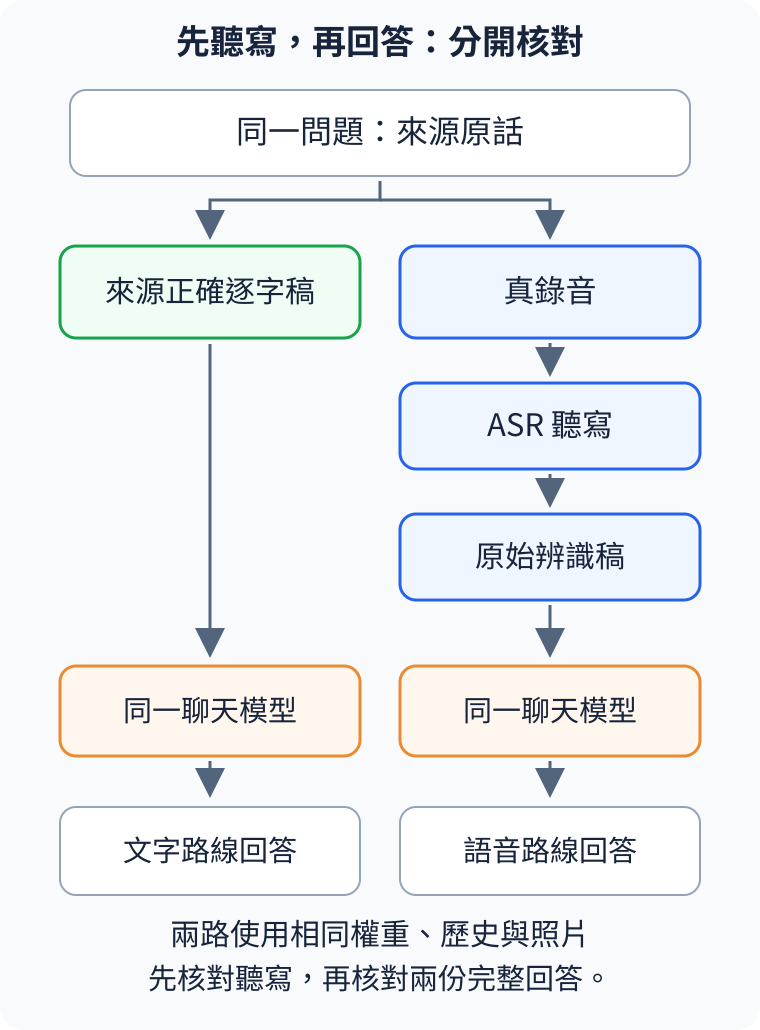

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/natural-v4-asr-two-routes.svg")))

In [3]:
from tiny_perceptron.natural_concepts import text_error_report

reference = "請推薦不辣的晚餐。"
recognized = "請推薦辣的晚餐。"
report = text_error_report(reference, recognized)
print("最少編輯次數", report["edits"])
print("參考字數", report["reference_characters"])
print("CER百分比", round(report["cer"] * 100, 1))
print("兩份問題相同", reference == recognized)

最少編輯次數 1
參考字數 9
CER百分比 11.1
兩份問題相同 False


人工漏字例需要補一次，原話含句號共9字，CER約11.1%，兩份問題不相同。一個否定詞就能反轉要求，所以平均字元差距不能代替條件是否保留。程式沒有播放錄音或生成回答。

真評測讓同一問句走兩路：一條把來源正確文字交給聊天，另一條把實際Whisper結果交給相同聊天。照片、歷史與要求固定。正確文字也答錯，就繼續查聊天；正確文字能答、錄音路線不能，則先查ASR的關鍵字。

AISHELL來源提供朗讀錄音與逐字稿，助理答覆判準由本課另訂。這不是即興長聊天，也沒有驗收所有噪聲、口音或多人重疊。介面人工更正可以幫助使用，卻要把更正前結果保留作原路線評測。
